=== ЧАСТЬ 1: целочисленный случай ===
ЦЕЛОЧИСЛЕННЫЙ ГА
Начальная популяция: [2, 3, 5, 4]
Бит: 3, кроссинговер после бита 1, мутация: 0.3
------------------------------------------------------------

--- Поколение 1 ---
  Популяция: [2, 3, 5, 4], f = [-0.33, 7.25, 7.92, 10.33]
    [0, 1, 1] x [1, 0, 1] -> [0, 0, 1], [1, 1, 1]
    [0, 1, 0] x [1, 0, 0] -> [0, 0, 0], [1, 1, 0]
  Потомки: [1, 7, 0, 6] -> после мутации: [1, 7, 2, 6]
  Финальная: [1, 2, 2, 6], лучший f = -5.42

--- Поколение 2 ---
  Популяция: [1, 2, 2, 6], f = [-5.42, -0.33, -0.33, 5.0]
    [0, 0, 1] x [1, 1, 0] -> [0, 1, 0], [1, 0, 1]
    [0, 1, 0] x [0, 1, 0] -> [0, 1, 0], [0, 1, 0]
  Потомки: [2, 5, 2, 2] -> после мутации: [2, 7, 6, 0]
  Финальная: [1, 2, 2, 2], лучший f = -5.42

--- Поколение 3 ---
  Популяция: [1, 2, 2, 2], f = [-5.42, -0.33, -0.33, -0.33]
    [0, 1, 0] x [0, 0, 1] -> [0, 0, 1], [0, 1, 0]
    [0, 1, 0] x [0, 1, 0] -> [0, 1, 0], [0, 1, 0]
  Потомки: [1, 2, 2, 2] -> после мутации: [3, 2, 2, 2]
  Финальна

[ Info: Saved animation to c:\programming\optimization-methods\lab17\integer_evolution.gif


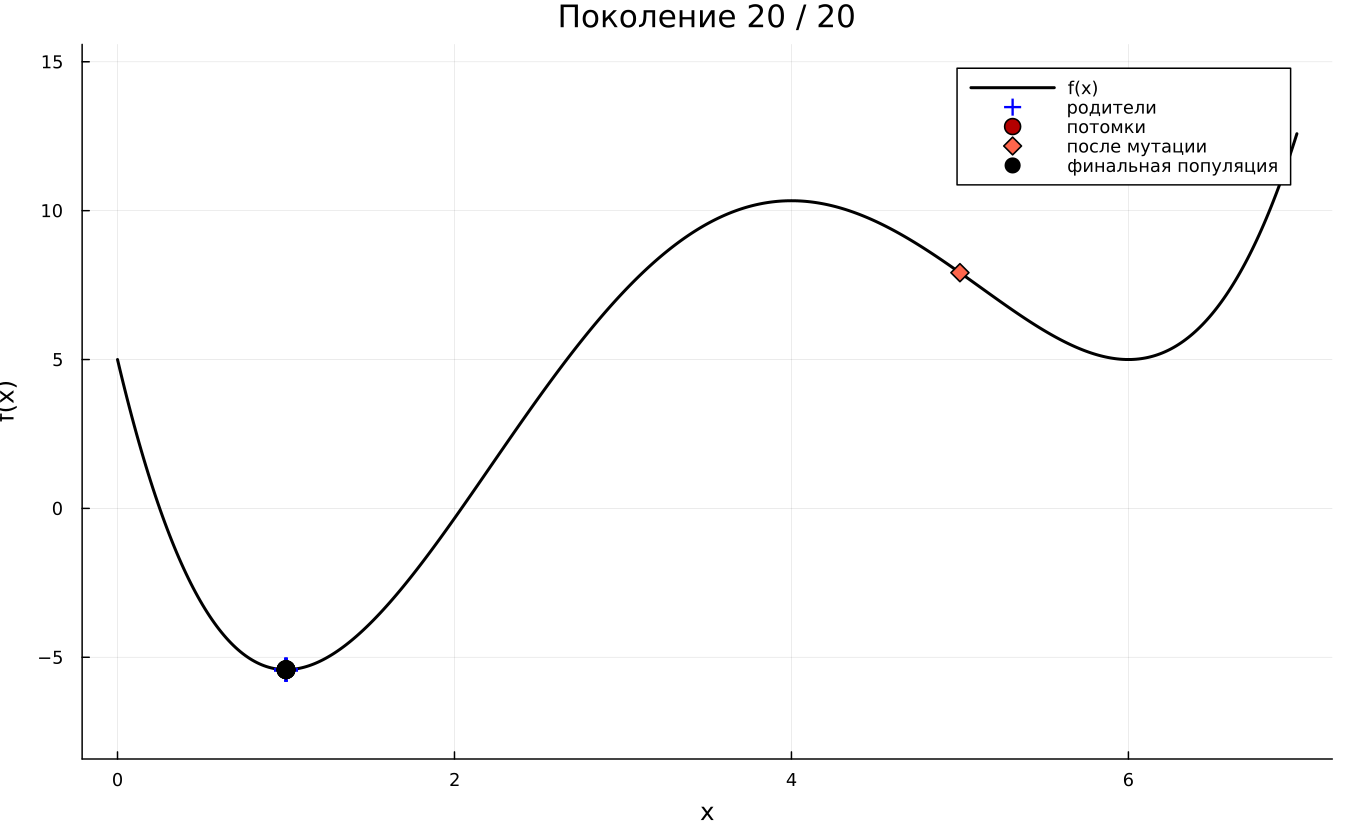

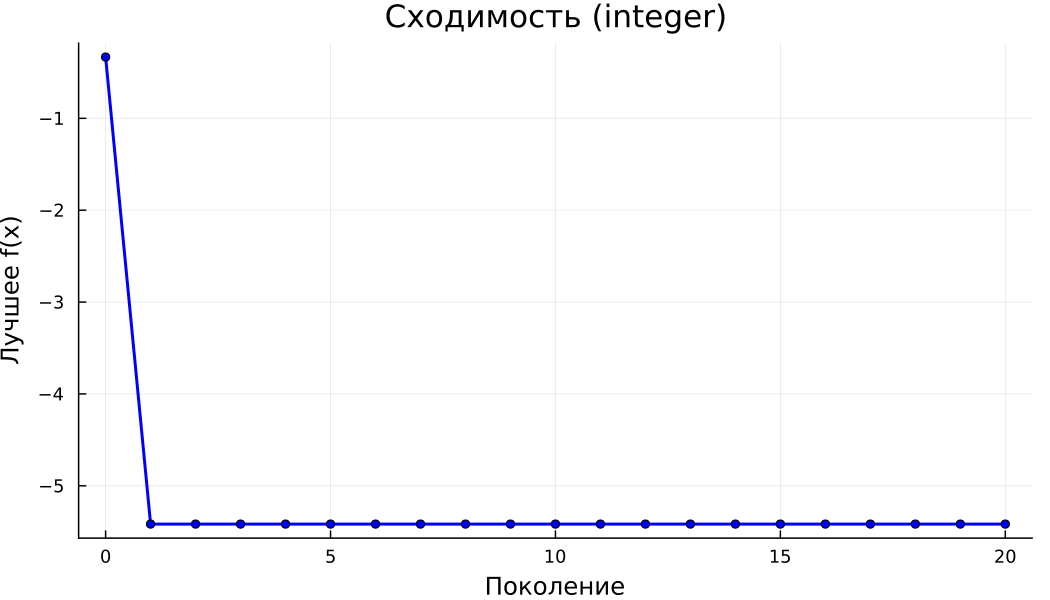


=== ЧАСТЬ 2: непрерывный случай ===

НЕПРЕРЫВНЫЙ ГА
Бит: 10, кроссинговер: 5, мутация: 0.15
Начальная популяция: [3.65, 4.11, 6.24, 1.34, 3.68, 2.73]
------------------------------------------------------------
  Поколение 1: лучший x=1.34, f=-4.6511
  Поколение 11: лучший x=1.12, f=-5.3132
  Поколение 21: лучший x=1.01, f=-5.4159
  Поколение 31: лучший x=1.01, f=-5.4159
  Поколение 41: лучший x=1.01, f=-5.4159
  Поколение 51: лучший x=1.01, f=-5.4159
  Поколение 61: лучший x=1.01, f=-5.4159
  Поколение 71: лучший x=1.01, f=-5.4159
  Поколение 81: лучший x=1.01, f=-5.4159
  Поколение 91: лучший x=1.01, f=-5.4159
  Поколение 100: лучший x=1.01, f=-5.4159
Сохранён: lab17/continuous_final.png
Сохранён: lab17/continuous_convergence.png
Сохранён: lab17\continuous_evolution.gif


[ Info: Saved animation to c:\programming\optimization-methods\lab17\continuous_evolution.gif


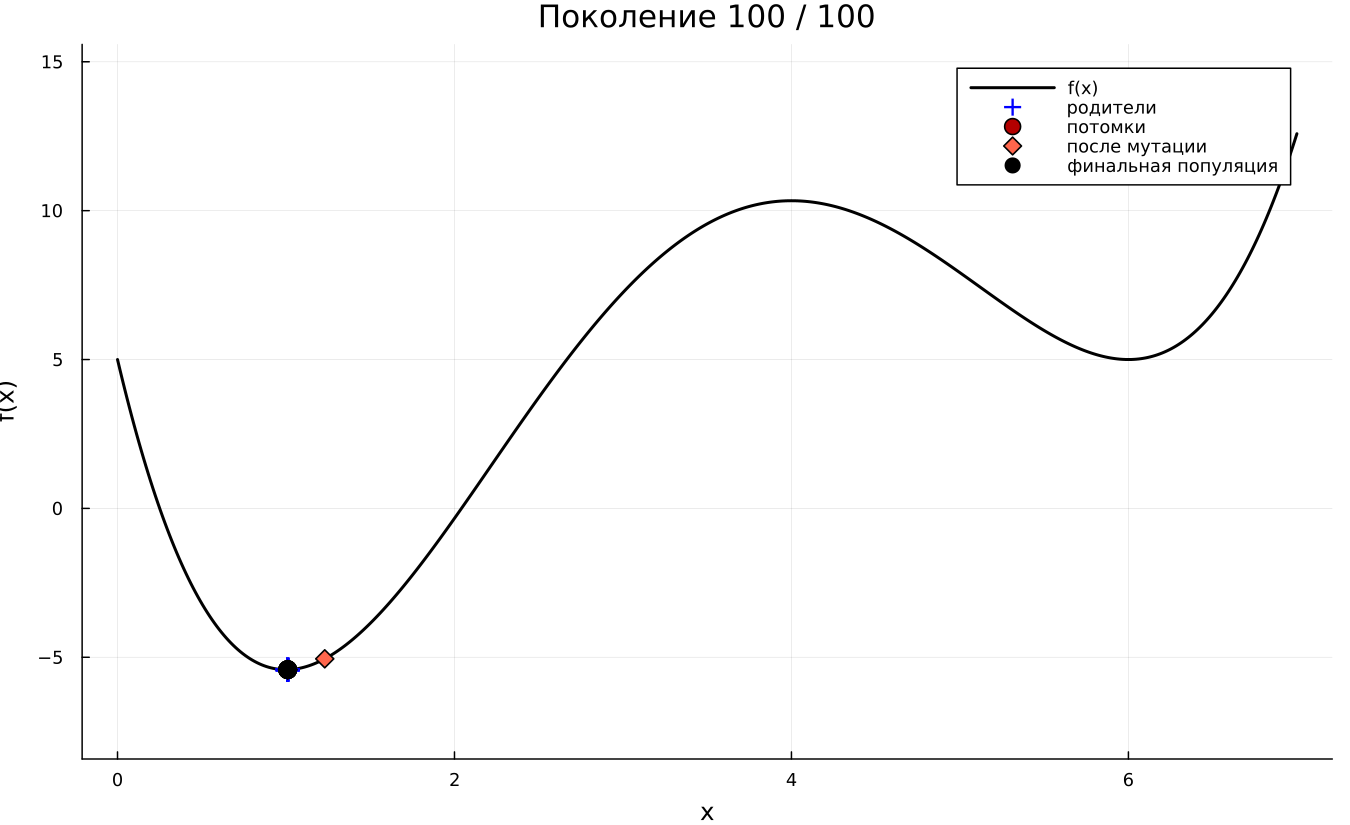

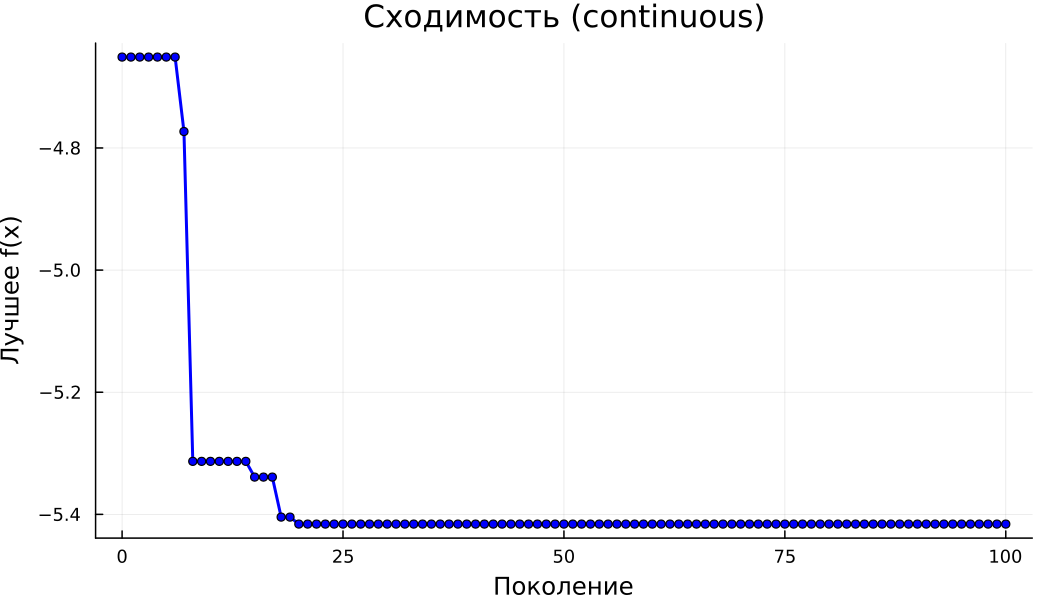


=== ЧАСТЬ 3: эксперименты ===
Сохранён: lab17/mutation_comparison.png


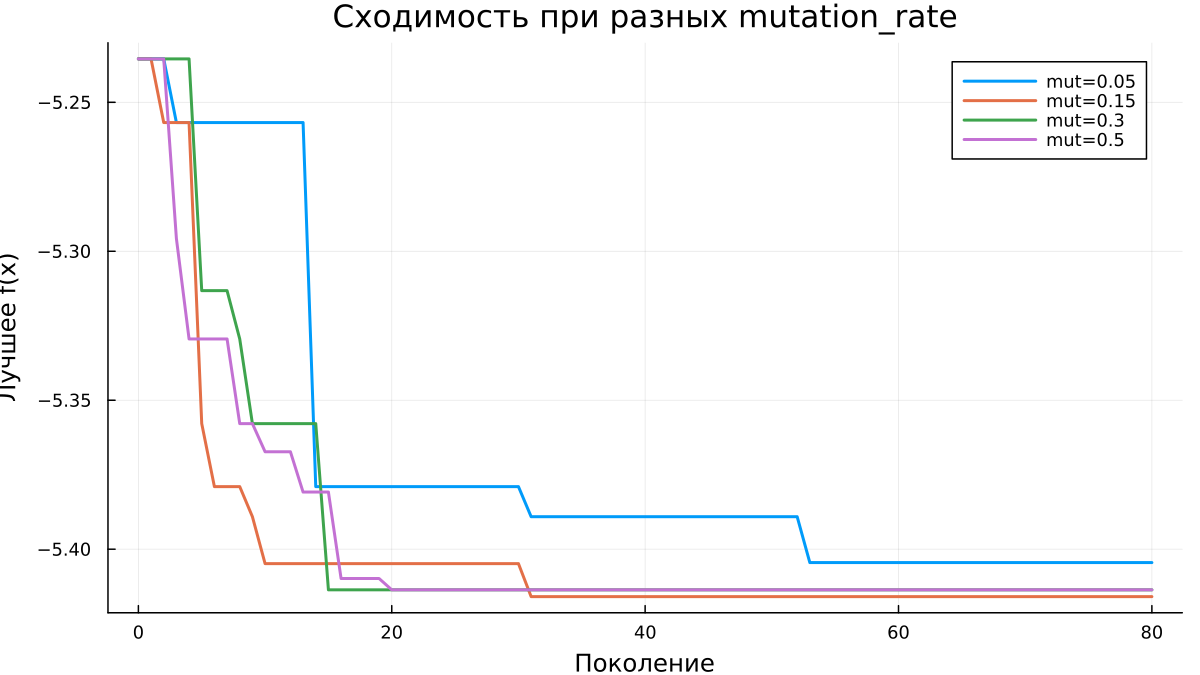

Сохранён: lab17/crossover_comparison.png


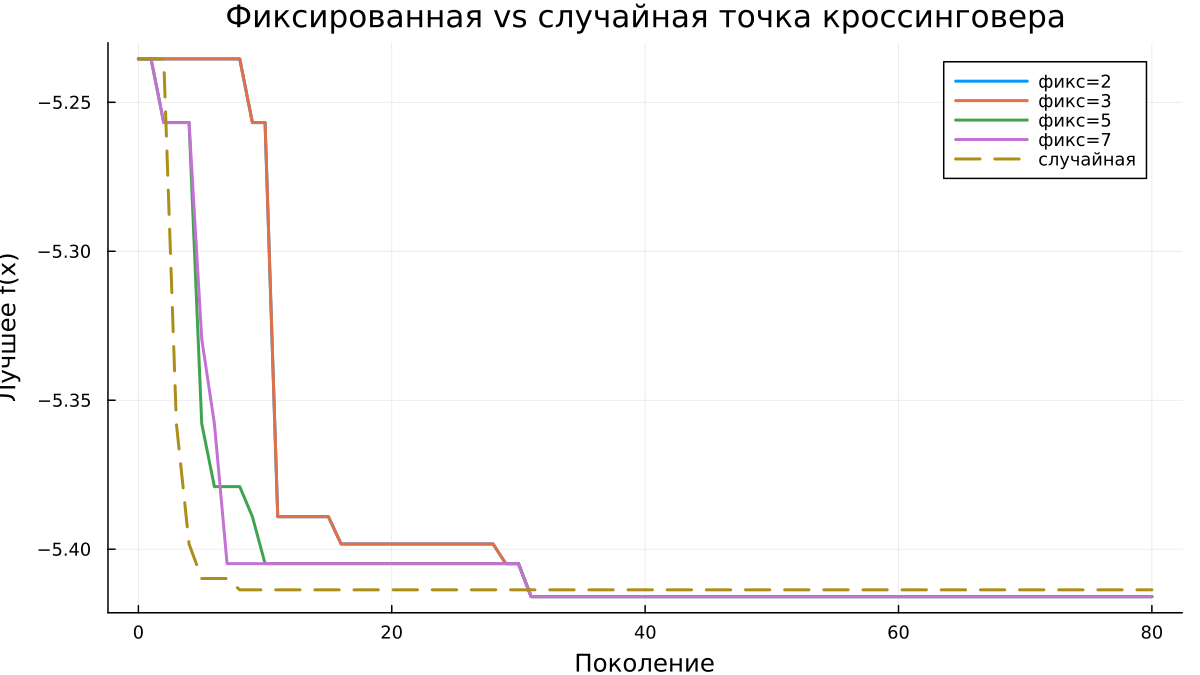


Готово! Все файлы в папке lab17/


In [4]:
# Генетический алгоритм — лаба 17
# f(x) = 5 - 24x + 17x^2 - (11/3)x^3 + (1/4)x^4
# Два режима: целочисленный (бинарное кодирование) и непрерывный (до сотых)

using Plots, Random

# --- конфиг ---
POP_SIZE = 4
MAX_GEN = 20
MUTATION_RATE = 0.3
SEED = 42
N_BITS = 3
CROSSOVER_PT = 1
INITIAL_POP = [2, 3, 5, 4]
X_MIN = 0.0
X_MAX = 7.0

# непрерывный случай
CONT_BITS = 10
CONT_CROSSOVER_PT = 5
CONT_POP_SIZE = 6
CONT_MAX_GEN = 100
CONT_MUTATION_RATE = 0.15
CONT_SEED = 123

SAVE_GIF = true
GIF_FPS = 2
OUTPUT_DIR = "lab17"

# целевая функция
f(x) = 5 - 24x + 17x^2 - (11/3)*x^3 + (1/4)*x^4

# бинарное кодирование
int_to_bits(x, nb) = digits(x, base=2, pad=nb) |> reverse
bits_to_int(bits) = sum(b * 2^(length(bits)-i) for (i,b) in enumerate(bits))

function float_to_bits(x, xmin, xmax, nb)
    norm = clamp((x - xmin) / (xmax - xmin), 0.0, 1.0)
    iv = round(Int, norm * (2^nb - 1))
    return int_to_bits(iv, nb)
end

function bits_to_float(bits, xmin, xmax)
    iv = bits_to_int(bits)
    return xmin + iv / (2^length(bits) - 1) * (xmax - xmin)
end

# кроссинговер
function crossover(p1, p2, point)
    c1 = vcat(p1[1:point], p2[point+1:end])
    c2 = vcat(p2[1:point], p1[point+1:end])
    return c1, c2
end

# мутация — инвертируем случайный бит с заданной вероятностью
function mutate!(bits, rate)
    if rand() < rate
        i = rand(1:length(bits))
        bits[i] = 1 - bits[i]
    end
    return bits
end

# визуализация одного поколения
# родители — синие крестики, потомки — тёмно-красные точки,
# после мутации — светло-красные ромбы, финальная популяция — чёрные точки
function plot_step(parents, offspring_before, offspring_after, final_pop, gen, total_gen)
    xs = range(X_MIN, X_MAX, length=500)
    ys = f.(xs)

    p = plot(xs, ys, lw=2, color=:black, label="f(x)",
        xlabel="x", ylabel="f(x)",
        title="Поколение $gen / $total_gen",
        legend=:topright, size=(900, 550), dpi=150,
        ylim=(minimum(ys)-3, maximum(ys)+3))

    scatter!(p, Float64.(parents), f.(parents),
        color=:blue, markershape=:cross, markersize=8, markerstrokewidth=2,
        label="родители")

    scatter!(p, Float64.(offspring_before), f.(offspring_before),
        color=RGB(0.7, 0.0, 0.0), markersize=6,
        label="потомки")

    scatter!(p, Float64.(offspring_after), f.(offspring_after),
        color=RGB(1.0, 0.4, 0.3), markersize=6, markershape=:diamond,
        label="после мутации")

    scatter!(p, Float64.(final_pop), f.(final_pop),
        color=:black, markersize=7,
        label="финальная популяция")

    return p
end

# целочисленный ГА
function run_integer_ga()
    Random.seed!(SEED)
    pop = copy(INITIAL_POP)

    frames = []
    best_history = [minimum(f.(pop))]

    println("=" ^ 60)
    println("ЦЕЛОЧИСЛЕННЫЙ ГА")
    println("Начальная популяция: $pop")
    println("Бит: $N_BITS, кроссинговер после бита $CROSSOVER_PT, мутация: $MUTATION_RATE")
    println("-" ^ 60)

    for gen in 1:MAX_GEN
        println("\n--- Поколение $gen ---")
        fitness = f.(pop)
        println("  Популяция: $pop, f = $(round.(fitness, digits=2))")

        encoded = [int_to_bits(x, N_BITS) for x in pop]

        # кроссинговер
        idx = randperm(length(pop))
        offspring_bits = Vector{Vector{Int}}()
        for i in 1:2:length(idx)
            if i+1 > length(idx)
                push!(offspring_bits, copy(encoded[idx[i]]))
                continue
            end
            c1, c2 = crossover(encoded[idx[i]], encoded[idx[i+1]], CROSSOVER_PT)
            push!(offspring_bits, c1)
            push!(offspring_bits, c2)
            println("    $(encoded[idx[i]]) x $(encoded[idx[i+1]]) -> $c1, $c2")
        end

        offspring_before = [bits_to_int(b) for b in offspring_bits]

        # мутация
        for bits in offspring_bits
            mutate!(bits, MUTATION_RATE)
        end
        offspring_after = [bits_to_int(b) for b in offspring_bits]

        println("  Потомки: $offspring_before -> после мутации: $offspring_after")

        # отбор — берём лучших из родителей + потомков
        all_ind = vcat(pop, offspring_after)
        all_fit = f.(all_ind)
        si = sortperm(all_fit)
        new_pop = all_ind[si[1:POP_SIZE]]

        push!(frames, plot_step(pop, offspring_before, offspring_after, new_pop, gen, MAX_GEN))

        pop = new_pop
        push!(best_history, minimum(f.(pop)))
        println("  Финальная: $pop, лучший f = $(round(best_history[end], digits=2))")
    end

    return pop, best_history, frames
end

# непрерывный ГА
function run_continuous_ga()
    Random.seed!(CONT_SEED)
    pop = [round(X_MIN + rand() * (X_MAX - X_MIN), digits=2) for _ in 1:CONT_POP_SIZE]

    frames = []
    best_history = [minimum(f.(pop))]

    println("\n" * "=" ^ 60)
    println("НЕПРЕРЫВНЫЙ ГА")
    println("Бит: $CONT_BITS, кроссинговер: $CONT_CROSSOVER_PT, мутация: $CONT_MUTATION_RATE")
    println("Начальная популяция: $(round.(pop, digits=2))")
    println("-" ^ 60)

    for gen in 1:CONT_MAX_GEN
        encoded = [float_to_bits(x, X_MIN, X_MAX, CONT_BITS) for x in pop]

        idx = randperm(length(pop))
        offspring_bits = Vector{Vector{Int}}()
        for i in 1:2:length(idx)
            if i+1 > length(idx)
                push!(offspring_bits, copy(encoded[idx[i]]))
                continue
            end
            c1, c2 = crossover(encoded[idx[i]], encoded[idx[i+1]], CONT_CROSSOVER_PT)
            push!(offspring_bits, c1)
            push!(offspring_bits, c2)
        end

        offspring_before = [round(bits_to_float(b, X_MIN, X_MAX), digits=2) for b in offspring_bits]

        for bits in offspring_bits
            mutate!(bits, CONT_MUTATION_RATE)
        end
        offspring_after = [round(bits_to_float(b, X_MIN, X_MAX), digits=2) for b in offspring_bits]

        all_ind = vcat(pop, offspring_after)
        all_fit = f.(all_ind)
        si = sortperm(all_fit)
        new_pop = all_ind[si[1:CONT_POP_SIZE]]

        push!(frames, plot_step(pop, offspring_before, offspring_after, new_pop, gen, CONT_MAX_GEN))

        pop = new_pop
        bv = minimum(f.(pop))
        push!(best_history, bv)

        if gen % 10 == 1 || gen == CONT_MAX_GEN
            println("  Поколение $gen: лучший x=$(round(pop[1], digits=2)), f=$(round(bv, digits=4))")
        end
    end

    return pop, best_history, frames
end

# сохранение + вывод в блокнот
function save_results(frames, best_history, prefix)
    mkpath(OUTPUT_DIR)

    savefig(frames[end], joinpath(OUTPUT_DIR, "$(prefix)_final.png"))
    println("Сохранён: $(OUTPUT_DIR)/$(prefix)_final.png")

    p_conv = plot(0:length(best_history)-1, best_history,
        xlabel="Поколение", ylabel="Лучшее f(x)",
        title="Сходимость ($prefix)",
        lw=2, color=:blue, marker=:circle, ms=3,
        legend=false, size=(700, 400), dpi=150)
    savefig(p_conv, joinpath(OUTPUT_DIR, "$(prefix)_convergence.png"))
    println("Сохранён: $(OUTPUT_DIR)/$(prefix)_convergence.png")

    if SAVE_GIF
        anim = Animation()
        for fr in frames
            frame(anim, fr)
        end
        gp = joinpath(OUTPUT_DIR, "$(prefix)_evolution.gif")
        gif(anim, gp, fps=GIF_FPS)
        println("Сохранён: $gp")
    end

    display(frames[end])
    display(p_conv)
end

# эксперименты с параметрами
function run_experiments()
    mkpath(OUTPUT_DIR)

    # разные mutation_rate
    rates = [0.05, 0.15, 0.3, 0.5]
    p1 = plot(title="Сходимость при разных mutation_rate",
        xlabel="Поколение", ylabel="Лучшее f(x)",
        size=(800, 450), dpi=150, legend=:topright)
    for mr in rates
        Random.seed!(42)
        pop = [round(X_MIN + rand()*(X_MAX-X_MIN), digits=2) for _ in 1:CONT_POP_SIZE]
        bh = [minimum(f.(pop))]
        for gen in 1:80
            enc = [float_to_bits(x, X_MIN, X_MAX, CONT_BITS) for x in pop]
            idx = randperm(length(pop))
            ob = Vector{Vector{Int}}()
            for i in 1:2:length(idx)
                if i+1 > length(idx)
                    push!(ob, copy(enc[idx[i]]))
                    continue
                end
                c1, c2 = crossover(enc[idx[i]], enc[idx[i+1]], CONT_CROSSOVER_PT)
                push!(ob, c1); push!(ob, c2)
            end
            for b in ob; mutate!(b, mr); end
            ov = [round(bits_to_float(b, X_MIN, X_MAX), digits=2) for b in ob]
            all_i = vcat(pop, ov)
            si = sortperm(f.(all_i))
            pop = all_i[si[1:CONT_POP_SIZE]]
            push!(bh, minimum(f.(pop)))
        end
        plot!(p1, 0:length(bh)-1, bh, label="mut=$mr", lw=2)
    end
    savefig(p1, joinpath(OUTPUT_DIR, "mutation_comparison.png"))
    println("Сохранён: $(OUTPUT_DIR)/mutation_comparison.png")
    display(p1)

    # фиксированные vs случайная точка кроссинговера
    # фиксированные точки + "random" (каждый раз случайная от 1 до nb-1)
    fixed_cps = [2, 3, 5, 7]
    labels_cp = ["фикс=$cp" for cp in fixed_cps]
    push!(labels_cp, "случайная")

    p2 = plot(title="Фиксированная vs случайная точка кроссинговера",
        xlabel="Поколение", ylabel="Лучшее f(x)",
        size=(800, 450), dpi=150, legend=:topright)

    for (k, lbl) in enumerate(labels_cp)
        is_random = (k > length(fixed_cps))
        cp_fixed = is_random ? 0 : fixed_cps[k]

        Random.seed!(42)
        pop = [round(X_MIN + rand()*(X_MAX-X_MIN), digits=2) for _ in 1:CONT_POP_SIZE]
        bh = [minimum(f.(pop))]
        for gen in 1:80
            enc = [float_to_bits(x, X_MIN, X_MAX, CONT_BITS) for x in pop]
            idx = randperm(length(pop))
            ob = Vector{Vector{Int}}()
            for i in 1:2:length(idx)
                if i+1 > length(idx)
                    push!(ob, copy(enc[idx[i]]))
                    continue
                end
                # для каждой пары выбираем точку: фиксированную или случайную
                cp = is_random ? rand(1:CONT_BITS-1) : cp_fixed
                c1, c2 = crossover(enc[idx[i]], enc[idx[i+1]], cp)
                push!(ob, c1); push!(ob, c2)
            end
            for b in ob; mutate!(b, CONT_MUTATION_RATE); end
            ov = [round(bits_to_float(b, X_MIN, X_MAX), digits=2) for b in ob]
            all_i = vcat(pop, ov)
            si = sortperm(f.(all_i))
            pop = all_i[si[1:CONT_POP_SIZE]]
            push!(bh, minimum(f.(pop)))
        end
        style = is_random ? :dash : :solid
        plot!(p2, 0:length(bh)-1, bh, label=lbl, lw=2, linestyle=style)
    end
    savefig(p2, joinpath(OUTPUT_DIR, "crossover_comparison.png"))
    println("Сохранён: $(OUTPUT_DIR)/crossover_comparison.png")
    display(p2)
end

# запуск
println("=== ЧАСТЬ 1: целочисленный случай ===")
pop_int, bh_int, frames_int = run_integer_ga()
save_results(frames_int, bh_int, "integer")

println("\n=== ЧАСТЬ 2: непрерывный случай ===")
pop_cont, bh_cont, frames_cont = run_continuous_ga()
save_results(frames_cont, bh_cont, "continuous")

println("\n=== ЧАСТЬ 3: эксперименты ===")
run_experiments()

println("\nГотово! Все файлы в папке $OUTPUT_DIR/")